In [1]:
# Import needed python libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from ctgan import CTGAN
from imblearn.over_sampling import RandomOverSampler

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [2]:
# Loading the classification dataset
data = pd.read_csv('drug.csv')

In [3]:
# Display the first few rows of the dataset
data.head() 

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [4]:
# Shape of the dataset
data.shape

(200, 6)

In [5]:
# As we have only 200 data we can use CTGAN to generate more data
# lest seperate categorical columns
cat = ["Sex", "BP", "Cholesterol", "Drug"]

# Initialize CTGAN model
ctgan = CTGAN(epochs=300)

# Fit the model on the original data
ctgan.fit(data, discrete_columns=cat)

# Generate synthetic data
synthetic_data = ctgan.sample(1000)

# Combine original and synthetic data
combined_data = pd.concat([data, synthetic_data], ignore_index=True)

# Check the shape of the combined data
combined_data.shape


(1200, 6)

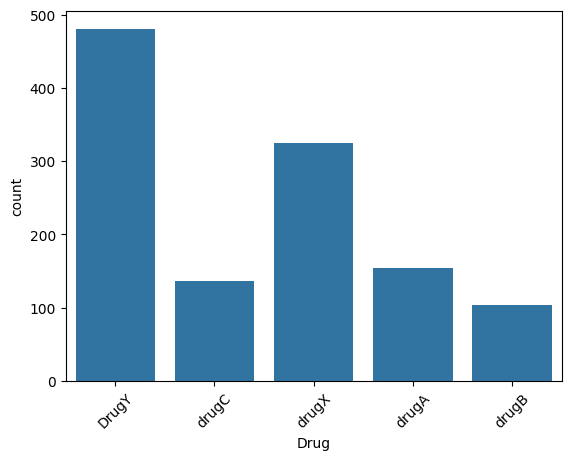

In [6]:
# Check class distribution for new combined data
sns.countplot(data=combined_data, x="Drug")
plt.xticks(rotation=45)
plt.show()


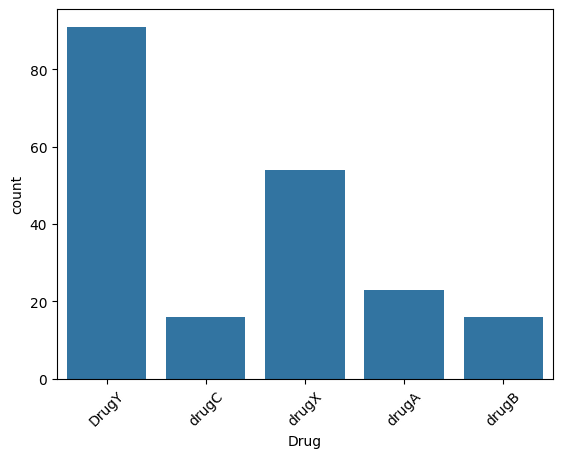

In [7]:
# Check class distribution for original data
sns.countplot(data=data, x="Drug")
plt.xticks(rotation=45)
plt.show()


In [8]:
# Describe the combined data
combined_data.describe()

,Age,Na_to_K
count,1200.000000,1200.000000
mean,52.163333,21.833858
std,18.940053,9.981589
min,3.000000,2.922405
25%,39.000000,14.008941
50%,51.000000,19.945947
75%,67.000000,27.704641
max,95.000000,49.297692


In [9]:
# Lets use MAD for Noise management
df = combined_data.copy()


In [10]:
df.shape

(1200, 6)

In [11]:
# Creating a function to identify outliers using MAD
# Z score beyond threshold will be considered as outlier
def mad_outliers(series, threshold=3.5):
    median = series.median()
    mad = np.median(np.abs(series - median))

    # In case all values are the same, then No outliers
    if mad == 0:
        return pd.Series([False]*len(series))
    
    # For other cases lets see if z score is beyond threshold---> if yes the outlier_mask true
    modified_z_scores = 0.6745 * (series - median) / mad
    return np.abs(modified_z_scores) > threshold

# Apply MAD to numeric columns
numeric_cols = ['Age', 'Na_to_K']

# Making a new dataframe which has outlier mask true or false
outlier_mask = pd.DataFrame({
    col: mad_outliers(df[col])
    for col in numeric_cols
})

# Find rows with any outlier for given colums and making a data series called rows_with_outlier from the dataframe called outlier_mask
rows_with_outlier = outlier_mask.any(axis=1)

# Remove noise/outliers
clean_df = df[~rows_with_outlier]

In [12]:
# We have new dataframe now 
clean_df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [13]:
clean_df.shape

(1200, 6)

Before remove noises we had 1200 data whereas after remove noises we have 1155 data